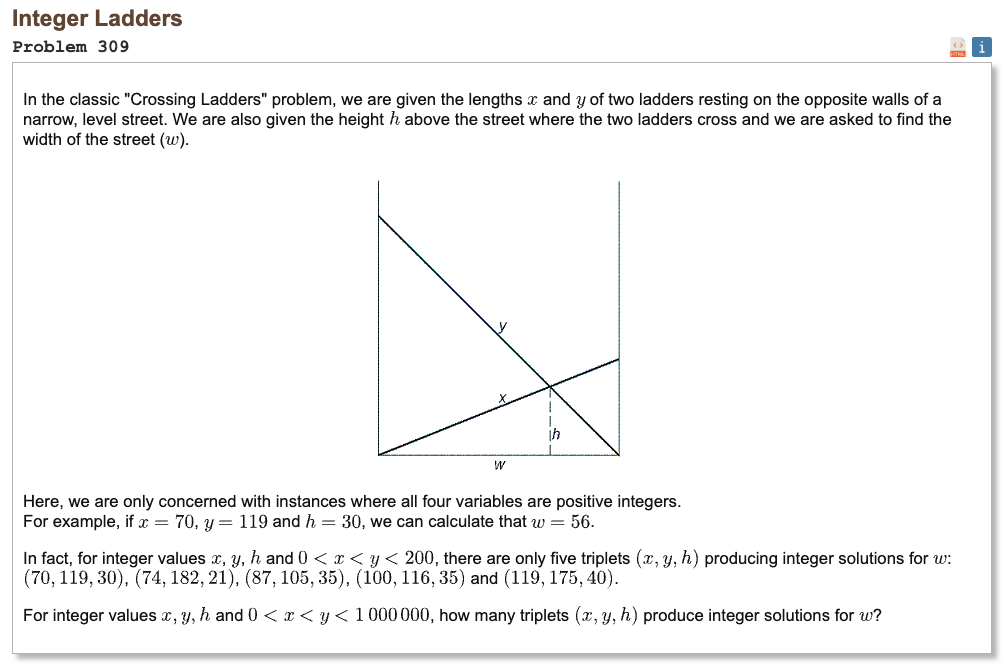

## Initial approach

* treat each ladder as part of a right triangle
* the street width is the shared horizontal side
* generate all integer right triangles with ladder length below the limit
* group possible wall heights by the same street width
* test every pair of heights that shares the same width
* count the pair only when the crossing height is also an integer
* this avoids solving the geometry directly for every possible ladder pair

In [1]:
import math

def solve(limit):
    heights_by_width = [[] for _ in range(limit + 1)]

    max_m = int(math.isqrt(limit)) + 1

    for m in range(2, max_m + 1):
        for n in range(1, m):
            if ((m - n) & 1) == 0:
                continue

            if math.gcd(m, n) != 1:
                continue

            a = m * m - n * n
            b = 2 * m * n
            c = m * m + n * n

            if c >= limit:
                break

            k = 1
            while k * c < limit:
                ka = k * a
                kb = k * b

                heights_by_width[ka].append(kb)
                heights_by_width[kb].append(ka)

                k += 1

    total = 0

    for heights in heights_by_width:
        if len(heights) < 2:
            continue

        heights.sort()

        for i in range(len(heights)):
            a = heights[i]

            for j in range(i + 1, len(heights)):
                b = heights[j]

                if (a * b) % (a + b) == 0:
                    total += 1

    return total

In [2]:
%%time
result = solve(1_000_000)
print("Result:", result)

Result: 210139
CPU times: user 4.03 s, sys: 42.3 ms, total: 4.07 s
Wall time: 4.08 s
